#*OH binding energies on PtNi alloy

PtNi alloys rank among the most studied ORR catalysts for a reason: Ni pulls the d-band center of the surface Pt layer downward, weakening OH adsorption relative to pure Pt and nudging the surface closer to the volcano peak. The complication is that an alloy is not a single structure. A Pt50Ni50 slab has  an enormous number of atomic arrangements in the subsurface layers, and each arrangement produces a slightly different local environment above the adsorption site. The binding energy is not a number but a distribution. Knowing that one very specific atomic arrangement gives an exceptional catalyst is satisfying but useless in practice.

There is a term in materials engineering for attempting to replicate a catalyst atom by atom: **Insanity**.

This notebook captures that distribution through statistical sampling. For each target composition, 100 random alloy configurations are generated by assigning each bulk-layer atom to Pt or Ni with probability proportional to the composition, then relaxing each configuration with OH adsorbed using the UMA machine-learning potential under a loose convergence threshold (fmax = 0.2, 10 steps) to enable rapid screening. Two compositions are compared, Pt50Ni50 and Pt90Ni10, alongside pure Pt and a Ni slab with a Pt skin as reference points. The resulting binding energy histograms are interpreted against the ORR volcano to identify which composition sits closest to the theoretical optimum.

In [1]:
%%capture
!pip install fairchem-core --upgrade
!pip install ase

The UMA model is distributed under the FAIR Chemistry License by Meta, available at https://huggingface.co/facebook/UMA/blob/main/LICENSE. By running this notebook you agree to its terms. To use the model in your own environment, go to Hugging Face (huggingface.co), create an account, generate an access token under Settings > Access Tokens, and download the model via the fairchem API. Since tokens are personal and should not be shared, in this notebook we provide the model file via a direct Google Drive link instead.

In [2]:
!gdown 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

Downloading...
From (original): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX
From (redirected): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX&confirm=t&uuid=0c5c17a4-72e6-47a2-ad5c-ca000198c81a
To: /content/uma-s-1p1.pt
100% 1.17G/1.17G [00:17<00:00, 67.0MB/s]


In [7]:
from ase import Atoms
from ase.build import fcc111, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.io import Trajectory
from ase.optimize import FIRE
from ase.visualize import view

from fairchem.core import FAIRChemCalculator
from fairchem.core.units.mlip_unit import MLIPPredictUnit

import matplotlib.pyplot as plt
import numpy as np
import os


In [4]:
model_path = '/content/uma-s-1p1.pt'
predictor = MLIPPredictUnit(model_path, device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

We define two dictionaries that will be reused throughout the notebook: one storing literature lattice parameters for a wide range of FCC metals, and one storing pre-built adsorbate geometries. Having these in one place makes it easy to switch metals or adsorbates without modifying the calculation code.

In [5]:
lat_param_dict = {'Pt': 3.9936, 'Ni': 3.565}

adsorbate_dict = {'OH': Atoms('OH', ([0, 0, 0], [0.65, 0.65, 0.40]))}

### Descriptor Method

Descriptors are properties or characteristics of a catalyst material that correlate with its catalytic activity and selectivity. In the context of ORR, these descriptors are used to predict the performance of different catalysts without having to test each one experimentally. The descriptor method helps in screening potential catalyst materials quickly by focusing on key properties that influence their catalytic behavior.

OH intermediate is a crucial species in the ORR mechanism. The interaction between the catalyst and the OH intermediate is often used as a descriptor for the catalytic performance. Oxygen reduction reaction (ORR) involves multiple steps, including the adsorption and reduction of O₂, and the formation and removal of intermediates like OH. The binding energy of OH on the catalyst surface is a key factor that influences the overall reaction rate. The OH binding energy serves as a primary descriptor because it directly impacts the energy barriers of the reaction steps. An optimal OH binding energy indicates a good balance between adsorption and desorption of intermediates.

Common descriptors for ORR include binding energies of reaction intermediates like oxygen (O₂), hydroxyl (OH), and oxygenated species (OOH). Theoretical calculations are employed to determine these binding energies. By comparing these values, researchers can predict which materials might be more effective catalysts.

Volcano plots are graphical representations that depict the relationship between the catalytic activity of a material and its binding energy of a key intermediate. The peak of the volcano represents the optimal binding energy, where the catalytic activity is highest. Materials on the left side of the peak bind the intermediate too strongly, making it difficult for the intermediate to desorb and proceed to the next step in the reaction. Materials on the right side bind the intermediate too weakly, making it difficult for the intermediate to form in the first place. By plotting different materials on the volcano plot, researchers can identify which materials are closest to the optimal binding energy and are thus promising candidates for further study.

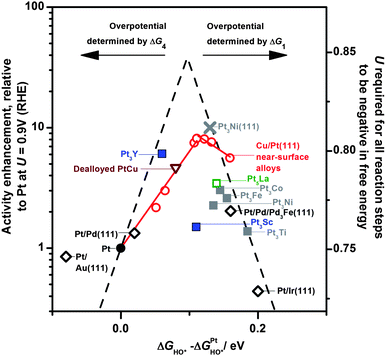

Volcano plot for different catalysts with Pt-overlayers. Source:https://pubs.rsc.org/en/content/articlelanding/2012/ee/c2ee03590a

Example Process:

Calculate Descriptors: Calculate the OH binding energy for various materials.

Analyze: Identify materials near the peak of the volcano plot as potential high-performance catalysts.

Experiment: Test the identified materials experimentally to validate the theoretical predictions.

Here I will write an introduction about ORR, volcano, descriptor method.

https://pubs.rsc.org/en/content/articlelanding/2012/ee/c2ee03590a



## Pure Metal Calculations (Pt, Ni)

We start with pure Pt(111) and a Ni slab with a Pt skin as reference points. The Pt skin model places a single layer of Pt atoms on top of a Ni bulk, which is known to shift the d-band center and modify the OH binding energy relative to pure Pt.

In [9]:
##-Making the Pt slab and constraining the bottom two layers
atoms = fcc111('Pt', (3, 3, 5), a=lat_param_dict['Pt'], vacuum=10)
atoms.set_constraint(FixAtoms(indices=[a.index for a in atoms if a.tag > 3]))

adsorbate = adsorbate_dict['OH']

##-Adding OH as the adsorbate
add_adsorbate(atoms, adsorbate, height=2.0, position='ontop')

##-View
view(atoms, viewer='x3d')

In [10]:
atoms.pbc = [True, True, True]
atoms.calc = calc

In [11]:
%%time
##-Calculating the slab with OH
opt = FIRE(atoms, trajectory='PtOH.traj')
opt.run(fmax=0.1, steps=25)

      Step     Time          Energy          fmax
FIRE:    0 14:09:54     -245.196520        1.039039
FIRE:    1 14:09:57     -245.221566        0.633524
FIRE:    2 14:10:00     -245.242257        0.903606
FIRE:    3 14:10:03     -245.268389        0.799539
FIRE:    4 14:10:06     -245.289793        0.358338
FIRE:    5 14:10:09     -245.294484        0.705794
FIRE:    6 14:10:11     -245.296917        0.570179
FIRE:    7 14:10:15     -245.300203        0.324665
FIRE:    8 14:10:17     -245.302345        0.120733
FIRE:    9 14:10:20     -245.302833        0.330036
FIRE:   10 14:10:23     -245.303028        0.311221
FIRE:   11 14:10:26     -245.303392        0.274989
FIRE:   12 14:10:29     -245.303867        0.224072
FIRE:   13 14:10:32     -245.304393        0.165056
FIRE:   14 14:10:34     -245.304913        0.107444
FIRE:   15 14:10:37     -245.305395        0.092538
CPU times: user 43.6 s, sys: 1.72 s, total: 45.3 s
Wall time: 46.1 s


np.True_

In [12]:
view(atoms, viewer='x3d')

### Calculations for OH binding energy on pure Ni slab with Pt skin

In [13]:
##-Making the Ni slab and constraining the bottom two layers
atoms = fcc111('Ni', (3, 3, 5), a=lat_param_dict['Ni'], vacuum=10)
atoms.set_constraint(FixAtoms(indices=[a.index for a in atoms if a.tag > 3]))

##-Making Pt skin
for atom in atoms:
  if atom.tag == 1:
    atom.symbol = 'Pt'

##-Adding OH as the adsorbate
adsorbate = adsorbate_dict['OH']
add_adsorbate(atoms, adsorbate, height=2.0, position='ontop')

##-View
view(atoms, viewer='x3d')

In [14]:
%%time
atoms.pbc = [True, True, True]
atoms.calc = calc

opt = FIRE(atoms, trajectory='NiOH.traj')
opt.run(fmax=0.5, steps=50)

      Step     Time          Energy          fmax
FIRE:    0 14:10:42     -221.734668        1.985427
FIRE:    1 14:10:46     -222.205617        1.430190
FIRE:    2 14:10:50     -222.746005        1.428205
FIRE:    3 14:10:54     -223.046934        0.936669
FIRE:    4 14:10:58     -223.050102        1.018299
FIRE:    5 14:11:02     -223.064419        0.859699
FIRE:    6 14:11:07     -223.088323        0.583054
FIRE:    7 14:11:11     -223.114729        0.355532
CPU times: user 31.9 s, sys: 1.51 s, total: 33.4 s
Wall time: 33.7 s


np.True_

### Plotting OH binding energies for pure Pt and Ni slabs

In [15]:
##-Read energies from trajectory files
PtOH_traj = Trajectory('PtOH.traj')
energy_PtOH = PtOH_traj[-1].get_potential_energy()

NiOH_traj = Trajectory('NiOH.traj')
energy_NiOH = NiOH_traj[-1].get_potential_energy()

To convert the raw slab energies into adsorption energies, we need the energy of the clean slab and a gas-phase OH reference. The adsorption energy is then simply the difference between the slab with adsorbate, the clean slab, and the OH reference.

In [16]:
##-Clean Pt slab, no adsorbate
atoms_Pt = fcc111('Pt', (3, 3, 5), a=lat_param_dict['Pt'], vacuum=10)
atoms_Pt.set_constraint(FixAtoms(indices=[a.index for a in atoms_Pt if a.tag > 3]))
atoms_Pt.pbc = [True, True, True]
atoms_Pt.calc = calc
energy_Pt_slab = atoms_Pt.get_potential_energy()

##-Clean Ni slab with Pt skin, no adsorbate
atoms_Ni = fcc111('Ni', (3, 3, 5), a=lat_param_dict['Ni'], vacuum=10)
atoms_Ni.set_constraint(FixAtoms(indices=[a.index for a in atoms_Ni if a.tag > 3]))

for atom in atoms_Ni:
  if atom.tag == 1:
    atom.symbol = 'Pt'

atoms_Ni.pbc = [True, True, True]
atoms_Ni.calc = calc
energy_Ni_slab = atoms_Ni.get_potential_energy()

##-H2O reference, gas phase
h2o_ref = Atoms('H2O', positions=[(0, 0, 0), (0.96, 0, 0), (0, 0.96, 0)])
h2o_ref.pbc = [False, False, False]
h2o_ref.calc = calc
energy_H2O_ref = h2o_ref.get_potential_energy()

##-H2 reference, gas phase
h2_ref = Atoms('H2', positions=[(0, 0, 0), (0.74, 0, 0)])
h2_ref.pbc = [False, False, False]
h2_ref.calc = calc
energy_H2_ref = h2_ref.get_potential_energy()

##-Print out the data values for debugging
e_PtOH = energy_PtOH - energy_Pt_slab - energy_H2O_ref + 0.5 * energy_H2_ref
e_NiOH = energy_NiOH - energy_Ni_slab - energy_H2O_ref + 0.5 * energy_H2_ref

print('e_PtOH =', e_PtOH)
print('e_NiOH =', e_NiOH)

e_PtOH = -2.5378942110793736
e_NiOH = -3.299181279228447


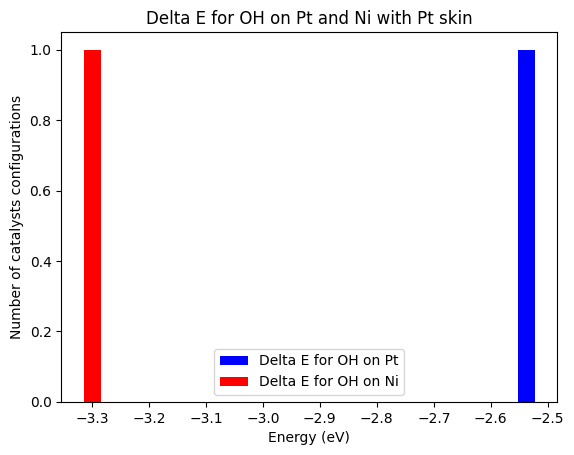

In [17]:
##-Plotting the Delta E histograms for OH
plt.bar(e_PtOH, 1, color='blue', label='Delta E for OH on Pt', width=0.03)
plt.bar(e_NiOH, 1, color='red', label='Delta E for OH on Ni', width=0.03)

plt.title('Delta E for OH on Pt and Ni with Pt skin')
plt.xlabel('Energy (eV)')
plt.ylabel('Number of catalysts configurations')
plt.legend()
plt.savefig('Delta_OH_Pt_Ni.png')
plt.show()

##  Alloy Calculations (PtNi)

In [18]:
##-Visualizing alloy
##-Define the elements and their proportions
elements = ['Pt', 'Ni']

##-Here we can change the composition probabilities
proportions = [0.50, 0.50]

##-Calculate the weighted mean lattice parameter
mean_lat_param = sum(p * lat_param_dict[element] for p, element in zip(proportions, elements))

##-Making the Pt slab and constraining the bottom two layers, 45 atoms
atoms = fcc111('Pt', (3, 3, 5), a=mean_lat_param, vacuum=10)
atoms.set_constraint(FixAtoms(indices=[a.index for a in atoms if a.tag > 3]))

##-Making the Pt skin by only assigning Ni element symbols to the atoms under the top layer based on probabilities
bulk_atoms = [a for a in atoms if a.tag not in [0, 1]]

for a in bulk_atoms:
  a.symbol = np.random.choice(elements, p=proportions)

##-Adding OH adsorbate
adsorbate = adsorbate_dict['OH']
add_adsorbate(atoms, adsorbate, height=2.0, position='ontop')

##-View alloy slab
view(atoms, viewer='x3d')

This code randomly generates 100 alloy slab configurations per composition, does a quick relaxation with OH adsorbed, and saves each trajectory to disk for statistical analysis of binding energy distributions.

In [19]:
%%time
##-This takes 10 mins
amount_of_traj = 100

proportions_list = [
  [0.50, 0.50],
  [0.90, 0.10]
]

elements = ['Pt', 'Ni']

for proportions in proportions_list:
  directory = f'PtNi_{int(proportions[0] * 100)}_{int(proportions[1] * 100)}'
  os.makedirs(directory, exist_ok=True)

  mean_lat_param = sum(p * lat_param_dict[element] for p, element in zip(proportions, elements))

  for i in range(amount_of_traj):
    atoms = fcc111('Pt', (3, 3, 5), a=mean_lat_param, vacuum=10)
    atoms.set_constraint(FixAtoms(indices=[a.index for a in atoms if a.tag > 3]))

    bulk_atoms = [a for a in atoms if a.tag not in [0, 1]]

    for a in bulk_atoms:
      a.symbol = np.random.choice(elements, p=proportions)

    atoms.pbc = [True, True, True]
    atoms.calc = calc

    adsorbate = adsorbate_dict['OH']
    add_adsorbate(atoms, adsorbate, height=2.0, position='ontop')

    traj_filename = os.path.join(directory, f'{i}.traj')
    opt = FIRE(atoms, trajectory=traj_filename)
    opt.run(fmax=2, steps=10)

      Step     Time          Energy          fmax
FIRE:    0 14:11:24     -235.814522        2.681653
FIRE:    1 14:11:29     -236.402128        2.056282
FIRE:    2 14:11:34     -237.085932        1.207629
      Step     Time          Energy          fmax
FIRE:    0 14:11:39     -237.452511        2.149071
FIRE:    1 14:11:45     -237.915754        1.626411
      Step     Time          Energy          fmax
FIRE:    0 14:11:49     -236.833031        2.566405
FIRE:    1 14:11:55     -237.489863        1.919096
      Step     Time          Energy          fmax
FIRE:    0 14:12:00     -235.563381        2.843539
FIRE:    1 14:12:05     -235.842471        2.203647
FIRE:    2 14:12:11     -236.155926        1.184275
      Step     Time          Energy          fmax
FIRE:    0 14:12:16     -237.239759        2.130420
FIRE:    1 14:12:21     -237.473968        1.783338
      Step     Time          Energy          fmax
FIRE:    0 14:12:26     -234.526016        1.961567
      Step     Time     

## Combined Binding energy distribution Plot

In [20]:
amount_of_traj = 100

PtOH_traj = Trajectory('PtOH.traj')
energy_PtOH = PtOH_traj[-1].get_potential_energy()

NiOH_traj = Trajectory('NiOH.traj')
energy_NiOH = NiOH_traj[-1].get_potential_energy()

e_PtOH = energy_PtOH - energy_Pt_slab - energy_H2O_ref + 0.5 * energy_H2_ref
e_NiOH = energy_NiOH - energy_Ni_slab - energy_H2O_ref + 0.5 * energy_H2_ref

elements = ['Pt', 'Ni']
all_energies = []

for proportions in proportions_list:
  mean_lat_param = sum(p * lat_param_dict[element] for p, element in zip(proportions, elements))

  ##-Clean slab reference for this composition
  ref_slab = fcc111('Pt', (3, 3, 5), a=mean_lat_param, vacuum=10)
  ref_slab.set_constraint(FixAtoms(indices=[a.index for a in ref_slab if a.tag > 3]))


  ##-Use mean composition for reference, no randomness
  ref_slab.pbc = [True, True, True]
  ref_slab.calc = calc
  energy_ref_slab = ref_slab.get_potential_energy()

  directory = f'PtNi_{int(proportions[0] * 100)}_{int(proportions[1] * 100)}'

  energies = []

  for i in range(amount_of_traj):
    traj = Trajectory(os.path.join(directory, f'{i}.traj'))
    energy = traj[-1].get_potential_energy()
    energy = energy - energy_ref_slab - energy_H2O_ref + 0.5 * energy_H2_ref
    energies.append(energy)

  all_energies.append(energies)

print('all_energies =', all_energies)

all_energies = [[-4.849415438703131, -5.679237654057756, -5.253346545768279, -3.919409508560262, -5.237451353753057, -2.28949960250871, -4.682639247250917, -3.51254197155343, -6.582072282073751, -4.104488274778857, -3.7733186629991002, -4.532692101848296, -1.6018450860137086, -6.4288038213066, -4.4146431826038235, -5.32829211428715, -4.17401247248044, -5.800046508747171, -3.024583029625217, -2.6245776077137584, -5.1536167883267705, -3.707852050449629, -5.352739701978278, -4.045600986528411, -4.798020529827097, -1.806084978240944, -3.328358824502954, -6.1632047489297985, -4.785312366851498, -3.6856690193400374, -4.407538966610856, -5.577584297923847, -3.499749208514243, -2.381002909066195, -5.0565333323477955, -4.953677945926598, -4.5116657833498675, -5.092453406653773, -7.117104693325173, -5.476733174549066, -3.703434183825278, -4.771242541577022, -4.278928409877677, -4.087600972422548, -4.215559240041115, -7.054442878491711, -6.254893676571426, -0.9756441444689989, -3.712215304428367,

With all trajectories computed, we collect the final energies and plot the binding energy distributions for both alloy compositions alongside the pure metal reference values. The width of each distribution reflects how sensitive the binding energy is to the local atomic environment.

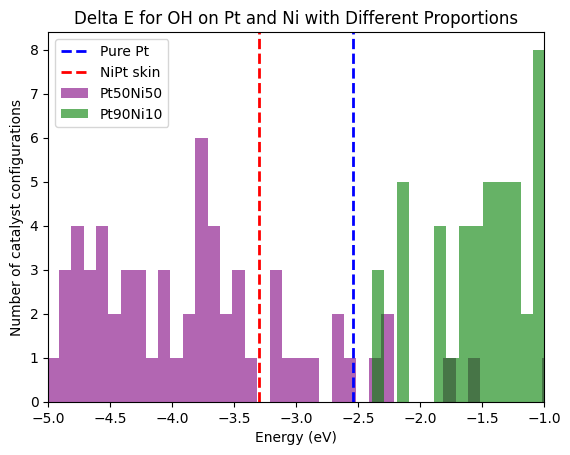

In [21]:
bin_width = 0.1

plt.axvline(e_PtOH, color='blue', linestyle='--', linewidth=2, label='Pure Pt')
plt.axvline(e_NiOH, color='red', linestyle='--', linewidth=2, label='NiPt skin')

colors = ['purple', 'green']
labels = ['Pt50Ni50', 'Pt90Ni10']

##-This loop was missing, add it
for energies, color, label in zip(all_energies, colors, labels):
  bins = np.arange(min(energies), max(energies) + bin_width, bin_width)
  plt.hist(energies, bins=bins, color=color, alpha=0.6, label=label)

plt.title('Delta E for OH on Pt and Ni with Different Proportions')
plt.xlabel('Energy (eV)')
plt.xlim(-5, -1)
plt.ylabel('Number of catalyst configurations')
plt.legend()
plt.savefig('Delta_OH_Pt_Ni_PtNi.png')
plt.show()

## Conclusion

The theoretical optimum for ORR in reference to Pt is 0.1 eV according to literature (source:https://pubs.rsc.org/en/content/articlelanding/2012/ee/c2ee03590a).

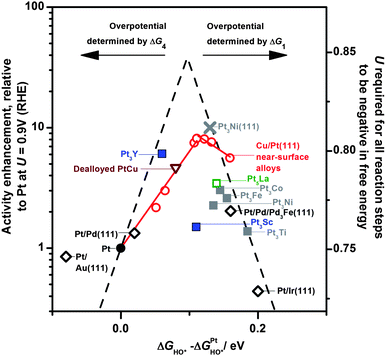

Volcano plot for different catalysts with Pt-overlayers.

The binding energy distribution is narrower when the composition is closer to pure Pt because there is less Ni and therefore the ligand effect from Ni has less influence.

From our calculations we find that Pt90Ni10 is closer to the optimum, and therefore is a better ORR catalyst than Pt50Ni50.

# Summary

After completing this notebook, you should be able to:


1. Build an FCC(111) slab with a composition-weighted mean lattice parameter, keep the surface layer as pure Pt (Pt skin model), and randomly assign each bulk-layer atom to an element using np.random.choice() with composition-dependent probabilities.
2. Loop over many configurations with a deliberately loose optimizer convergence threshold to capture the spread introduced by compositional disorder without converging each structure fully, and save each trajectory to a labelled directory for later analysis.
3. Use a single mean-composition clean slab as the reference for all random configurations of the same composition (avoiding the need to optimize a unique reference for each), and apply the standard H₂O/H₂ Hess cycle expression.
4. Plot and interpret binding energy distributions.
5. Compare Pt₉₀Ni₁₀ and Pt₅₀Ni₅₀ distributions against the theoretical ORR optimum (approximately 0.1 eV weaker than pure Pt according to the Nørskov volcano), identify which composition is better positioned, and articulate why Ni content improves activity up to a point before over-binding becomes the limiting factor.